In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sns.set_theme()

# PERT distribution for both unstarted and ongoing activities

In [5]:
# Generate random samples from a PERT-like distribution
def pert_sample(optimistic, most_probable, pessimistic, elapsed_time=0, 
                complete_percent=0,size=1000, lamb=4):

    # Planned estimates
    a=optimistic
    b=most_probable
    c=pessimistic

    # Compute alpha and Beta parameters
    alpha = 1 + lamb * (b-a) / (c-a)
    beta = 1 + lamb * (c-b) / (c-a)

    # Generate samples from Beta distribution
    samples = stats.beta.rvs(alpha, beta, size=size)

    # Scale samples to the feasible range
    samples = a + samples * (c-a)
    return samples if complete_percent == 0 else elapsed_time + (1-complete_percent) * samples	

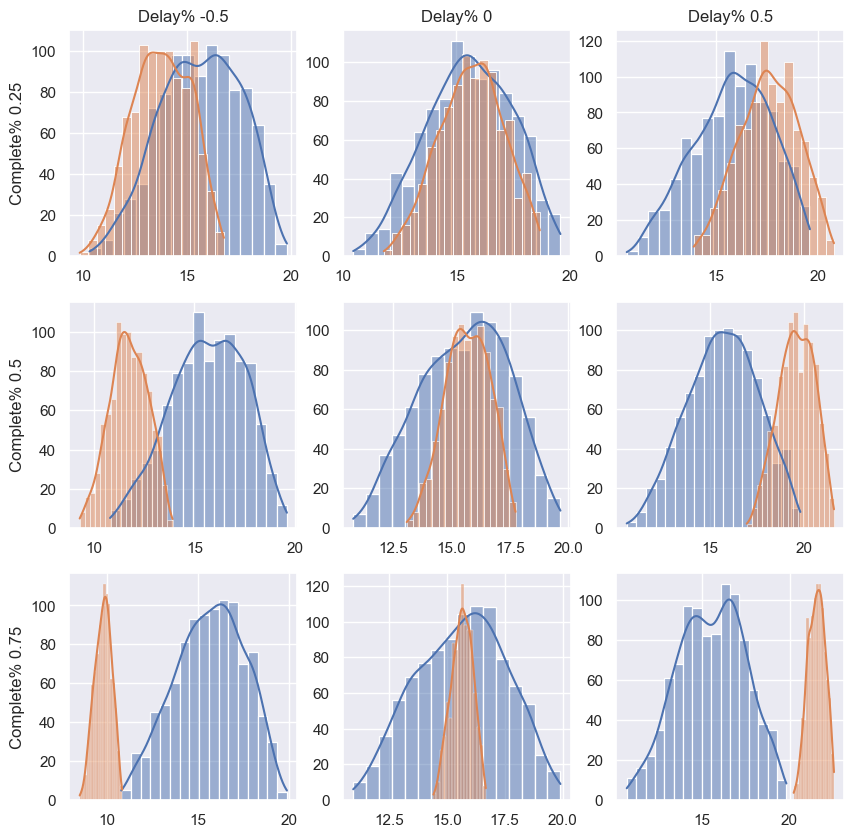

In [ ]:
plt.figure(figsize=(10,10))
for i,complete in enumerate([0.25,0.5,0.75]):
    for j,delay in enumerate([-0.5,0,0.5]):
        plt.subplot(3,3, 3*i+j+1)
        elapsed_time=complete*((10+4*16+20)/6)*(1+delay)
        g=sns.histplot(pert_sample(optimistic=10, most_probable=16, pessimistic=20, elapsed_time=0, complete_percent=0, size=1000),kde=True) # baseline
        g=sns.histplot(pert_sample(optimistic=10, most_probable=16, pessimistic=20, elapsed_time=elapsed_time, complete_percent=complete, size=1000),kde=True)
        g.set_ylabel('')
        if i==0: g.set_title(f'Delay% {delay}')
        if j==0: g.set_ylabel(f'Complete% {complete}')
